# TODO
Transfer daset from 1/12 to 1/4

- 1/4 daset oisst v2.1 :'/lustre/home/yuhanxue/data/oisst/V2.1/oisst-avhrr-v02r01.19810901.nc'
- 1/12 daset glorys s1v2 :'/lustre/home/yuhanxue/data/GLORYS/Area1/thetao&uo&vo_time1993-01-01~1993-01-31_LonMin195_LonMax230_LatMin35_LatMax50_DMax318.1274108886719.nc'

In [19]:
import os
import numpy as np
import scipy as sp
import pandas as pd
from datetime import date
import marineHeatWaves as mhw
import netCDF4 as nc
import datetime
import matplotlib.pyplot as plt 
from tqdm import notebook
from scipy.interpolate import griddata
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor

In [20]:
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/lat.npy')
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/lon.npy')-360
time=pd.to_datetime(np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/time.npy',allow_pickle=True))

In [21]:
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')

lat_4 range:70.00~0.00 | freq:0.25
lon_4 range:-240.00~-90.00 | freq:0.25


In [9]:
lat_12=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/lat.npy')
lon_12=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/lon.npy')

In [10]:
print(f'lat_12 range:{lat_12[0]:.2f}~{lat_12[-1]:.2f} | freq:{lat_12[1]-lat_12[0]}\nlon_12 range:{lon_12[0]:.2f}~{lon_12[-1]:.2f} | freq:{lon_12[1]-lon_12[0]}')

lat_12 range:35.00~50.00 | freq:0.08333206176757812
lon_12 range:-165.00~-130.00 | freq:0.0833282470703125


经上述数据观察需要将ERA/0.25数据集进行如下操作：  
* axis=lat 反转  
* axis=lat 缩小至35~50  
* axis=lon 缩小至-165~-130(165W~130W)  

需要将Glorys数据进行以下操作
* 加载数据  
* 生成插值网点  
* 二维插值  

## ERA/0.25 数据集操作

In [22]:
mslhfs=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/mslhfs.npy')
msnlwrfs=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/msnlwrfs.npy')
msnswrfs=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/msnswrfs.npy')
msshfs=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/msshfs.npy')

### axis=lat 反转

In [23]:
lat_4=lat_4[::-1]
mslhfs=mslhfs[:,::-1,:]
msnlwrfs=msnlwrfs[:,::-1,:]
msnswrfs=msnswrfs[:,::-1,:]
msshfs=msshfs[:,::-1,:]

### axis=lat 缩小至35~50 & axis=lon 缩小至-165~-130(165W~130W)

In [24]:
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=-165)&(lon_4<=-130)
#time_ind=(time.year>=1993)&(time.year<=2019)
mslhfs=mslhfs[:,lat_4_ind,:][:,:,lon_4_ind]
msnlwrfs=msnlwrfs[:,lat_4_ind,:][:,:,lon_4_ind]
msnswrfs=msnswrfs[:,lat_4_ind,:][:,:,lon_4_ind]
msshfs=msshfs[:,lat_4_ind,:][:,:,lon_4_ind]

In [ ]:
plt.plot(time,np.mean(np.mean(slhfs,axis=1),axis=1),label='SLHF')
plt.plot(time,np.mean(np.mean(sshfs,axis=1),axis=1),label='SSHF')
plt.plot(time,np.mean(np.mean(msnswrfs,axis=1),axis=1),label='msnswrfs')
plt.plot(time,np.mean(np.mean(msnlwrfs,axis=1),axis=1),label='msnlwrfs')
plt.legend()
plt.grid()

### 结束处理，数据回存

In [25]:
print(f'lat_4[lat_4_ind] range:{lat_4[lat_4_ind][0]:.2f}~{lat_4[lat_4_ind][-1]:.2f} | freq:{lat_4[lat_4_ind][1]-lat_4[lat_4_ind][0]}\nlon_4[lon_4_ind] range:{lon_4[lon_4_ind][0]:.2f}~{lon_4[lon_4_ind][-1]:.2f} | freq:{lon_4[lon_4_ind][1]-lon_4[lon_4_ind][0]}')
np.save(f'/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_mslhfs.npy',mslhfs)
np.save(f'/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msnlwrfs.npy',msnlwrfs)
np.save(f'/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msnswrfs.npy',msnswrfs)
np.save(f'/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msshfs.npy',msshfs)
np.save(f'/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msshfs.npy',msshfs)
np.save(f'/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_lat.npy',lat_4[lat_4_ind])
np.save(f'/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_lon.npy',lon_4[lon_4_ind])


lat_4[lat_4_ind] range:35.00~50.00 | freq:0.25
lon_4[lon_4_ind] range:-165.00~-130.00 | freq:0.25


In [18]:
1+1

2

## GLORYS数据处理

In [13]:
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=-165)&(lon_4<=-130)
Lon_4,Lat_4=np.meshgrid(lon_4[lon_4_ind],lat_4[lat_4_ind])
Lon_12,Lat_12=np.meshgrid(lon_12,lat_12)
points=np.array([Lon_12.flatten(),Lat_12.flatten()]).T
def grid(dat):
    global points,Lon_4,Lat_4
    return griddata(points,dat.flatten(),(Lon_4,Lat_4),'cubic')
def list_map(dat):
    return np.array(list(map(grid,dat)))

In [14]:
thetaos=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos.npy')

In [15]:
%%time
np.array(list(map(list_map,thetaos[0:2,:,:,:])))

CPU times: user 1min 22s, sys: 56.7 ms, total: 1min 22s
Wall time: 1min 23s


array([[[[289.23310191, 289.8359035 , 289.94357281, ..., 288.96429487,
          288.81048159, 289.19354992],
         [289.16498459, 289.28583789, 289.18915525, ..., 288.33073062,
          288.67351452, 289.13422194],
         [288.37833949, 287.92275918, 287.80556811, ..., 288.07364269,
          288.68596607, 289.15692771],
         ...,
         [278.15927764, 277.91610616, 277.6700049 , ..., 281.85299388,
          281.47139044, 281.25898161],
         [278.13071232, 277.79598531, 277.67220223, ..., 281.31977448,
          281.23407851, 281.12421187],
         [278.11459854, 277.81063419, 277.69197823, ..., 281.13007143,
          281.1080981 , 281.10956299]],

        [[289.23310191, 289.8359035 , 289.94357281, ..., 288.96429487,
          288.81048159, 289.19354992],
         [289.16498459, 289.28583789, 289.18915525, ..., 288.33073062,
          288.67351452, 289.13422194],
         [288.37833949, 287.92275918, 287.80556811, ..., 288.07364269,
          288.68596607, 289.15692

In [9]:
thetaos=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos.npy')
thetaos_new=np.array(list(map(list_map,thetaos[:,:,:,:])))
np.save('/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_new.npy',thetaos_new)

In [ ]:
np.save('/lustre/home/yuhanxue/data/GLORYS/area1_re/uos_new.npy',uos_new)

In [26]:
def runavg(ts, w):
    '''
    Performs a running average of an input time series using uniform window
    of width w. This function assumes that the input time series is periodic.
    Inputs:
      ts            Time series [1D numpy array]
      w             Integer length (must be odd) of running average window
    Outputs:
      ts_smooth     Smoothed time series
    Written by Eric Oliver, Institue for Marine and Antarctic Studies, University of Tasmania, Feb-Mar 2015
    '''
    # Original length of ts
    N = len(ts)
    # make ts three-fold periodic
    ts = np.append(ts, np.append(ts, ts))
    # smooth by convolution with a window of equal weights
    ts_smooth = np.convolve(ts, np.ones(w)/w, mode='same')
    # Only output central section, of length equal to the original length of ts
    ts = ts_smooth[N:2*N]
    return ts

def Clim(t, data, climatologyPeriod=[None,None],  windowHalfWidth=5, smoothPercentile=True, smoothPercentileWidth=31,alternateClimatology=False, Ly=False):
    T = len(t)
    year = np.zeros((T))
    month = np.zeros((T))
    day = np.zeros((T))
    doy = np.zeros((T))
    for i in range(T):
        year[i] = date.fromordinal(t[i]).year
        month[i] = date.fromordinal(t[i]).month
        day[i] = date.fromordinal(t[i]).day
    # Leap-year baseline for defining day-of-year values
    year_leapYear = 2012 # This year was a leap-year and therefore doy in range of 1 to 366
    t_leapYear = np.arange(date(year_leapYear, 1, 1).toordinal(),date(year_leapYear, 12, 31).toordinal()+1)
    dates_leapYear = [date.fromordinal(tt.astype(int)) for tt in t_leapYear]
    month_leapYear = np.zeros((len(t_leapYear)))
    day_leapYear = np.zeros((len(t_leapYear)))
    doy_leapYear = np.zeros((len(t_leapYear)))
    for tt in range(len(t_leapYear)):
        month_leapYear[tt] = date.fromordinal(t_leapYear[tt]).month
        day_leapYear[tt] = date.fromordinal(t_leapYear[tt]).day
        doy_leapYear[tt] = t_leapYear[tt] - date(date.fromordinal(t_leapYear[tt]).year,1,1).toordinal() + 1
    # Calculate day-of-year values
    for tt in range(T):
        doy[tt] = doy_leapYear[(month_leapYear == month[tt]) * (day_leapYear == day[tt])]

    # Constants (doy values for Feb-28 and Feb-29) for handling leap-years
    feb28 = 59
    feb29 = 60

    # Set climatology period, if unset use full range of available data
    if (climatologyPeriod[0] is None) or (climatologyPeriod[1] is None):
        climatologyPeriod[0] = year[0]
        climatologyPeriod[1] = year[-1]

    #
    # Calculate threshold and seasonal climatology (varying with day-of-year)
    #

    # if alternate temperature time series is supplied for the calculation of the climatology
    if alternateClimatology:
        tClim = alternateClimatology[0]
        tempClim = alternateClimatology[1]
        TClim = len(tClim)
        yearClim = np.zeros((TClim))
        monthClim = np.zeros((TClim))
        dayClim = np.zeros((TClim))
        doyClim = np.zeros((TClim))
        for i in range(TClim):
            yearClim[i] = date.fromordinal(tClim[i]).year
            monthClim[i] = date.fromordinal(tClim[i]).month
            dayClim[i] = date.fromordinal(tClim[i]).day
            doyClim[i] = doy_leapYear[(month_leapYear == monthClim[i]) * (day_leapYear == dayClim[i])]
    else:
        tempClim = data.copy()
        TClim = np.array([T]).copy()[0]
        yearClim = year.copy()
        monthClim = month.copy()
        dayClim = day.copy()
        doyClim = doy.copy() 
    lenClimYear = 366
    # Start and end indices
    clim_start = np.where(yearClim == climatologyPeriod[0])[0][0]
    clim_end = np.where(yearClim == climatologyPeriod[1])[0][-1]
    # Inialize arrays
    seas_climYear = np.NaN*np.zeros(lenClimYear)
    clim = {}
    clim['seas'] = np.NaN*np.zeros(TClim)
    # Loop over all day-of-year values, and calculate threshold and seasonal climatology across years
    for d in range(1,lenClimYear+1):
        # Special case for Feb 29
        if d == feb29:
            continue
        # find all indices for each day of the year +/- windowHalfWidth and from them calculate the threshold
        tt0 = np.where(doyClim[clim_start:clim_end+1] == d)[0] 
        # If this doy value does not exist (i.e. in 360-day calendars) then skip it
        if len(tt0) == 0:
            continue
        tt = np.array([])
        for w in range(-windowHalfWidth, windowHalfWidth+1):
            tt = np.append(tt, clim_start+tt0 + w)
        tt = tt[tt>=0] # Reject indices "before" the first element
        tt = tt[tt<TClim] # Reject indices "after" the last element
        seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
    # Special case for Feb 29
    seas_climYear[feb29-1] = 0.5*seas_climYear[feb29-2] + 0.5*seas_climYear[feb29]

    #return seas_climYear
    # Smooth if desired
    if smoothPercentile:
        # If the length of year is < 365/366 (e.g. a 360 day year from a Climate Model)
        if Ly:

            valid = ~np.isnan(seas_climYear)
            seas_climYear[valid] = runavg(seas_climYear[valid], smoothPercentileWidth)
        # >= 365-day year
        else:

            seas_climYear = runavg(seas_climYear, smoothPercentileWidth)

    #print(doy)
    #clim['seas'] = seas_climYear[doy.astype(int)-1]

    # Save vector indicating which points in temp are missing values
    #clim['missing'] = np.isnan(data)
    # Set all remaining missing temp values equal to the climatology
    #data[np.isnan(data)] = clim['seas'][np.isnan(data)]

    return seas_climYear[doy.astype(int)-1]


In [33]:
t=np.arange(date(1993,1,1).toordinal(),date(2021,12,31).toordinal()+1)
mltt_T=np.load('1_10mltt_t.npy')

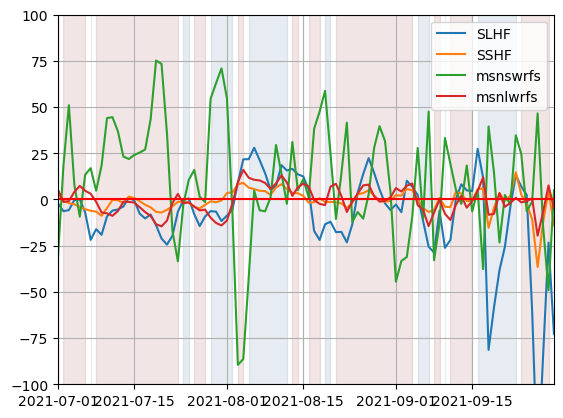

In [38]:
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1000
y0[:]=-1000
plt.plot(time,np.mean(np.mean(mslhfs,axis=1),axis=1)-Clim(t,np.mean(np.mean(mslhfs,axis=1),axis=1)),label='SLHF')
plt.plot(time,np.mean(np.mean(msshfs,axis=1),axis=1)-Clim(t,np.mean(np.mean(msshfs,axis=1),axis=1)),label='SSHF')
plt.plot(time,np.mean(np.mean(msnswrfs,axis=1),axis=1)-Clim(t,np.mean(np.mean(msnswrfs,axis=1),axis=1)),label='msnswrfs')
plt.plot(time,np.mean(np.mean(msnlwrfs,axis=1),axis=1)-Clim(t,np.mean(np.mean(msnlwrfs,axis=1),axis=1)),label='msnlwrfs')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=7)&(time.month<=9)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-100,100)
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()

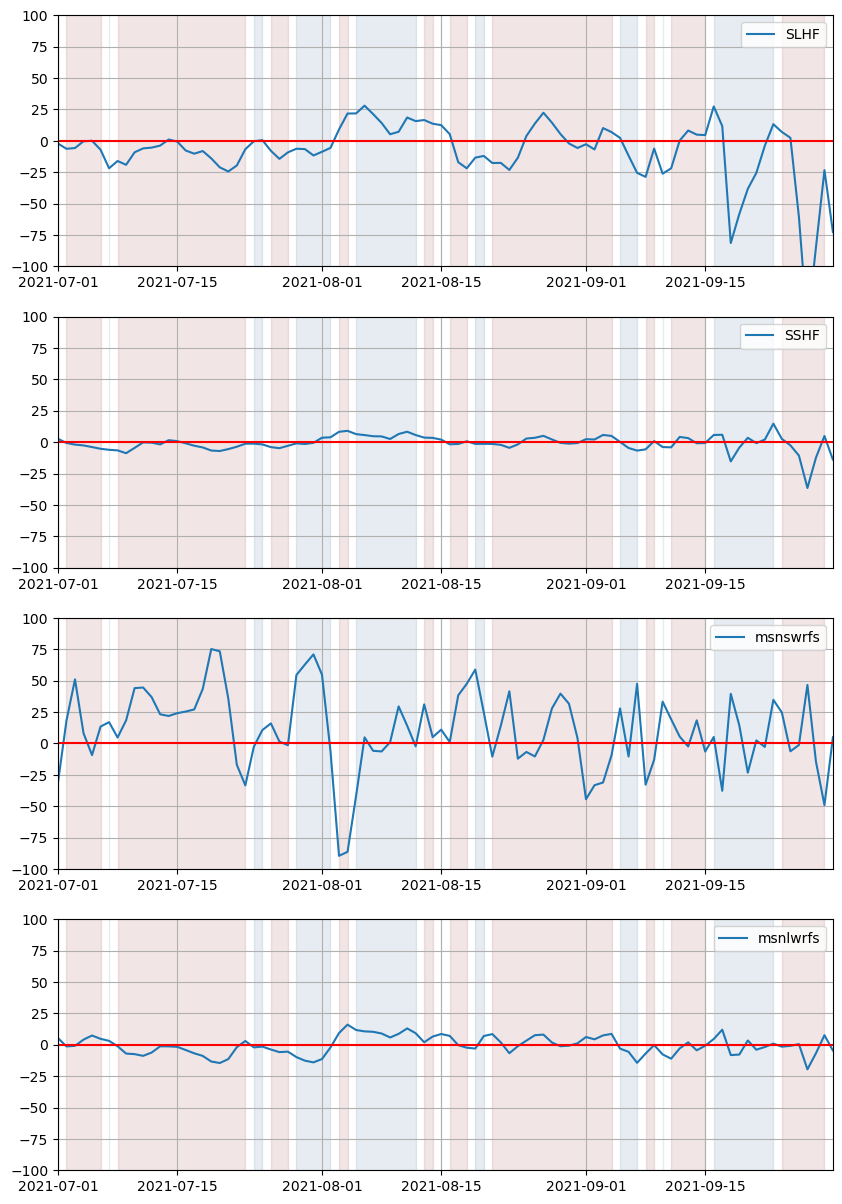

In [39]:
plt.figure(figsize=[10,15])
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1000
y0[:]=-1000
plt.subplot(4,1,1)
plt.plot(time,np.mean(np.mean(mslhfs,axis=1),axis=1)-Clim(t,np.mean(np.mean(mslhfs,axis=1),axis=1)),label='SLHF')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=7)&(time.month<=9)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-100,100)
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()

plt.subplot(4,1,2)
plt.plot(time,np.mean(np.mean(msshfs,axis=1),axis=1)-Clim(t,np.mean(np.mean(msshfs,axis=1),axis=1)),label='SSHF')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=7)&(time.month<=9)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-100,100)
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()

plt.subplot(4,1,3)
plt.plot(time,np.mean(np.mean(msnswrfs,axis=1),axis=1)-Clim(t,np.mean(np.mean(msnswrfs,axis=1),axis=1)),label='msnswrfs')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=7)&(time.month<=9)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-100,100)
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()

plt.subplot(4,1,4)
plt.plot(time,np.mean(np.mean(msnlwrfs,axis=1),axis=1)-Clim(t,np.mean(np.mean(msnlwrfs,axis=1),axis=1)),label='msnlwrfs')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=7)&(time.month<=9)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-100,100)
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[time_ind][:-1],y0[time_ind][:-1],y1[time_ind][:-1],where=np.nanmean(np.nanmean(mltt_T,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()


In [32]:
time[time_ind]

DatetimeIndex(['1993-01-01', '1993-01-02', '1993-01-03', '1993-01-04',
               '1993-01-05', '1993-01-06', '1993-01-07', '1993-01-08',
               '1993-01-09', '1993-01-10',
               ...
               '2019-12-22', '2019-12-23', '2019-12-24', '2019-12-25',
               '2019-12-26', '2019-12-27', '2019-12-28', '2019-12-29',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[ns]', length=9861, freq=None)

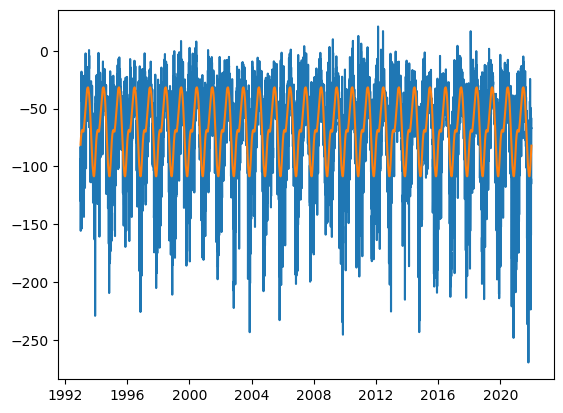

In [29]:
plt.plot(time,np.mean(np.mean(mslhfs,axis=1),axis=1),label='SLHF')
plt.plot(time,Clim(t,np.mean(np.mean(mslhfs,axis=1),axis=1)),label='SLHF')
